# 公式チュートリアル 05 — How to Log and Visualize Simulations
> 出典: https://ecell4.e-cell.org/tutorials/tutorial05.html

**Observer** がシミュレーション中の分子数や軌跡を記録する。代表: `FixedIntervalNumberObserver`（一定間隔）、
`TimingNumberObserver`（指定時刻）、`FixedIntervalHDF5Observer`（HDF5 保存）、`FixedIntervalTrajectoryObserver`（軌跡）。

targets: ['A', 'B', 'C']
logged rows: 101


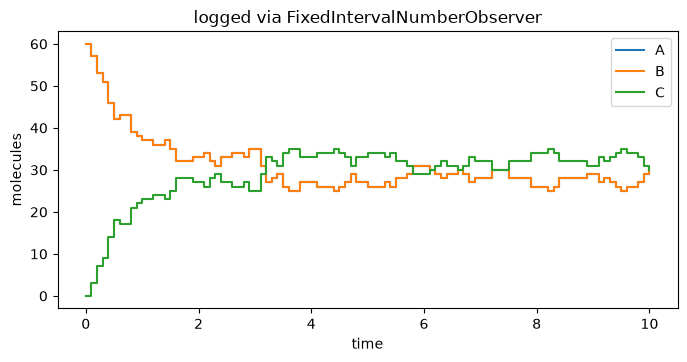

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4.prelude import *

with reaction_rules():
    A + B == C | (0.01, 0.3)
m = get_model()
w = gillespie.World(Real3(1,1,1)); w.bind_to(m)
w.add_molecules(Species('A'), 60); w.add_molecules(Species('B'), 60)
sim = gillespie.Simulator(w)

obs1 = FixedIntervalNumberObserver(0.1, ['A', 'B', 'C'])
sim.run(10.0, obs1)

print('targets:', [sp.serial() for sp in obs1.targets()])
data = np.array(obs1.data())          # 各行 = [t, A, B, C]
print('logged rows:', len(data))
plt.figure(figsize=(8,3.6))
for i,lab in enumerate(['A','B','C'],1): plt.step(data[:,0], data[:,i], where='post', label=lab)
plt.xlabel('time'); plt.ylabel('molecules'); plt.legend(); plt.title('logged via FixedIntervalNumberObserver'); plt.show()

**要点**: `sim.run(t, obs)` で記録しながら実行。`obs.data()` が `[t, 種1, 種2, ...]` の時系列、`obs.targets()` が種。
公式は `plotting.plot_number_observer(obs)` / `show(obs)` でワンライナー描画もできる（ここでは matplotlib で明示）。
複数 observer を `sim.run(t, [obs1, obs2])` で同時に。